# U-MobileViT-Net **BASE** - Mean Teacher Semi-Supervised Training

**Dataset**: COCO Tea Leaf | 8-class synthetic agricultural disease segmentation
**Model**: U-MobileViT-Net **Base** (d_model=64, ~0.6M parameters)
**Method**: Mean Teacher (Tarvainen & Valpola, 2017)
**Data Split**: 10% labeled / 90% unlabeled
**Metric**: Mean Intersection over Union (mIoU)
**Input resolution**: 320 x 320 pixels
**Training regime**: Batch size 16, 300 epochs, AdamW, PolyLR scheduler

This notebook trains the **base** variant using Mean Teacher semi-supervised
learning - direct counterpart to `01_base` (fully supervised).
Checkpoints are saved to `checkpoints/coco_leaf/semitrain_base/`.

In [1]:
# --- Section 1: Environment and Imports ----------------------------------------

import sys, os
from pathlib import Path
from itertools import cycle

# Locate project root by searching for .git or CLAUDE.md marker
current = Path.cwd()
project_root = current
for parent in [current] + list(current.parents):
    if (parent / '.git').exists() or (parent / 'CLAUDE.md').exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault('PYTHONPATH', str(project_root))
os.chdir(str(project_root))
print(f'Project root: {project_root}')

import numpy as np
import torch
from torch import nn
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt

from models.u_mobilevit_net.u_models import (
    umobilevit, UMobileViT, umobilevit_nano, umobilevit_base,
    umobilevit_pro, umobilevit_promax,
)
from models.u_mobilevit_net.configs import get_variant, UMOBILEVIT_VARIANTS
from tools.data import (
    create_dataloaders, DatasetInfo, label_to_color, denormalize,
    COCOLeafDataset, DATASET_INFO, DEFAULT_ROOTS,
)
from tools.training import (
    SegmentationTrainer, TrainingConfig,
    compute_class_weights, compute_pos_weight,
)
from tools.training_semi import (
    MeanTeacherConfig, MeanTeacherTrainer, sigmoid_rampup,
)
from tools.visualization import (
    configure_paper_style, plot_training_curves,
    show_dataset_samples, show_predictions,
    plot_per_class_iou, plot_confusion_matrix,
    plot_error_distribution, plot_params_vs_accuracy,
    plot_convergence_comparison, generate_results_table,
    load_training_history, load_all_results,
    TOL_PALETTE, VARIANT_COLORS,
)
from tools.evaluation import (
    compute_flops, compute_parameters, format_flops,
)

configure_paper_style()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


Project root: /run/media/sanng/New Volume/Seminar/U-MOBILEVIT-NET
Device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# --- Section 2: Configuration ---------------------------------------------------

def configure_experiment():
    return {
        'dataset': 'coco_leaf',
        'variant': 'base',
        'image_size': (320, 320),
        'batch_size': 16,
        'epochs': 25,
        'lr': 1e-2,
        'weight_decay': 1e-3,
        'warmup_epochs': 5,
        'scheduler': 'poly',
        'poly_power': 0.9,
        'aug_intensity': 'strong',
        'use_class_weights': True,
        'label_smoothing': 0.1,
        'patience': 30,
        'min_epochs': 50,
        # --- Mean Teacher specific ---
        'labeled_ratio': 0.1,
        'consistency_weight': 10.0,
        'teacher_ema_decay': 0.999,
        'consistency_rampup': 50,
    }

CFG = configure_experiment()

# Display variant specification
variant_spec = get_variant(CFG['variant'])
print(f"Model variant: {CFG['variant'].upper()}")
print(f"  d_model:             {variant_spec['d_model']}")
print(f"  Transformer blocks:  {variant_spec['num_transformer_blocks']}")
print(f"  Expansion factor:    {variant_spec['expansion_factor']}")
print(f"  Estimated params:    {variant_spec['params_estimate']}")
print()
print('Training configuration:')
for k, v in CFG.items():
    print(f'  {k:<25s} = {v}')
print()
print('Semi-supervised setup:')
print(f"  Labeled ratio:       {CFG['labeled_ratio']:.0%}")
print(f"  Consistency weight:  {CFG['consistency_weight']:.1f}")
print(f"  Teacher EMA decay:   {CFG['teacher_ema_decay']}")
print(f"  Consistency rampup:  {CFG['consistency_rampup']} epochs")


Model variant: BASE
  d_model:             64
  Transformer blocks:  2
  Expansion factor:    3.0
  Estimated params:    ~0.6M

Training configuration:
  dataset                   = coco_leaf
  variant                   = base
  image_size                = (320, 320)
  batch_size                = 16
  epochs                    = 100
  lr                        = 0.01
  weight_decay              = 0.001
  warmup_epochs             = 5
  scheduler                 = poly
  poly_power                = 0.9
  aug_intensity             = strong
  use_class_weights         = True
  label_smoothing           = 0.1
  patience                  = 30
  min_epochs                = 50
  labeled_ratio             = 0.1
  consistency_weight        = 10.0
  teacher_ema_decay         = 0.999
  consistency_rampup        = 50

Semi-supervised setup:
  Labeled ratio:       10%
  Consistency weight:  10.0
  Teacher EMA decay:   0.999
  Consistency rampup:  50 epochs


In [3]:
# --- Section 3: Semi-Supervised Data Loading ------------------------------------

def load_semi_supervised_data(config):
    """Create train/val DataLoaders with 10% labeled / 90% unlabeled split.

    Creates 2 separate unlabeled DataLoaders (student / teacher) from the
    same unlabeled subset so each branch sees different augmentations --
    this is the core mechanism of Mean Teacher (consistency under perturbation).
    """
    import numpy as np

    dataset_name = config['dataset']
    entry = DATASET_INFO[dataset_name]
    root = DEFAULT_ROOTS[dataset_name]
    image_size = config['image_size']
    batch_size = config['batch_size']
    aug_intensity = config['aug_intensity']
    labeled_ratio = config['labeled_ratio']

    # -- Full training dataset --
    full_train_ds = entry['train_class'](
        root=root, split='train', image_size=image_size,
        aug_intensity=aug_intensity,
    )
    n_total = len(full_train_ds)
    n_labeled = max(1, int(n_total * labeled_ratio))
    n_unlabeled = n_total - n_labeled

    # -- Deterministic split --
    rng = np.random.RandomState(42)
    indices = list(range(n_total))
    rng.shuffle(indices)
    labeled_indices = indices[:n_labeled]
    unlabeled_indices = indices[n_labeled:]

    # -- Labeled dataset + loader --
    labeled_ds = Subset(full_train_ds, labeled_indices)
    labeled_loader = DataLoader(
        labeled_ds, batch_size=batch_size, shuffle=True,
        num_workers=8, pin_memory=True, drop_last=True,
    )

    # -- 2 Unlabeled loaders: same subset, different shuffle order --
    # Each __getitem__ call produces different random augmentations
    unlabeled_ds = Subset(full_train_ds, unlabeled_indices)
    unlabeled_student_loader = DataLoader(
        unlabeled_ds, batch_size=batch_size, shuffle=True,
        num_workers=8, pin_memory=True, drop_last=True,
    )
    unlabeled_teacher_loader = DataLoader(
        unlabeled_ds, batch_size=batch_size, shuffle=True,
        num_workers=8, pin_memory=True, drop_last=True,
    )

    # -- Validation dataset (unchanged) --
    val_ds = entry['val_class'](
        root=root, split='val', image_size=image_size,
        aug_intensity='medium',
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=8, pin_memory=True,
    )

    # -- DatasetInfo --
    info = DatasetInfo(
        name=entry['name'],
        num_classes=entry['num_classes'],
        type=entry['type'],
        ignore_index=entry.get('ignore_index', 255),
        palette=entry.get('palette'),
        class_names=list(entry.get('class_names', [])),
        root=root,
        train_size=n_total,
        val_size=len(val_ds),
        image_size=image_size,
    )

    print(f"\nDataset: {info.name}")
    print(f"  Classes:          {info.num_classes} ({info.type})")
    names_str = ", ".join(info.class_names)
    print(f"  Class names:      {names_str}")
    print(f"  Input size:       {info.image_size}")
    print(f"  Ignore index:     {info.ignore_index}")
    print("  --- Semi-Supervised Split ---")
    print(f"  Labeled:          {n_labeled:,} images ({n_labeled/n_total*100:.1f}%)")
    print(f"  Unlabeled:        {n_unlabeled:,} images ({n_unlabeled/n_total*100:.1f}%)")
    print(f"  Validation:       {info.val_size:,} images")
    print(f"  Labeled batches:  {len(labeled_loader)}/epoch")
    print(f"  Unlabeled batches:{len(unlabeled_student_loader)}/epoch")

    return labeled_loader, unlabeled_student_loader, unlabeled_teacher_loader, val_loader, info

labeled_loader, unl_s_loader, unl_t_loader, val_loader, info = load_semi_supervised_data(CFG)



Dataset: COCO Tea Leaf
  Classes:          8 (multi-class)
  Class names:      healthy_leaf, brown_blight, red_spider_mite, red_rust, gray_blight, helopeltis, green_mirid_bug, tea_algal_leaf_spot
  Input size:       (320, 320)
  Ignore index:     255
  --- Semi-Supervised Split ---
  Labeled:          803 images (10.0%)
  Unlabeled:        7,235 images (90.0%)
  Validation:       1,962 images
  Labeled batches:  50/epoch
  Unlabeled batches:452/epoch


In [4]:
# --- Section 4: Model Initialisation -------------------------------------------

def build_model(info, variant='base'):
    factory = {
        'nano': umobilevit_nano,
        'base': umobilevit_base,
        'pro': umobilevit_pro,
        'promax': umobilevit_promax,
    }
    model = factory[variant](out_channels=info.num_classes, head='single')
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel: U-MobileViT-Net [{variant.upper()}]")
    print(f"  Parameters: {n_params:,} ({n_params / 1e6:.2f} M)")

    # Smoke test: verify output shape
    model.eval()
    with torch.no_grad():
        dummy = torch.randn(2, 3, *info.image_size)
        out = model(dummy)
        expected = (2, info.num_classes, *info.image_size)
        assert out.shape == expected, f"Shape mismatch: {tuple(out.shape)} vs {expected}"
        print(f"  Smoke test:  {tuple(dummy.shape)} -> {tuple(out.shape)}  PASSED")
    return model, n_params

model, n_params = build_model(info, CFG['variant'])

# NaN weight check
model = model.to(device)
nan_params = [n for n, p in model.named_parameters() if not torch.isfinite(p).all()]
if nan_params:
    raise RuntimeError(f"{len(nan_params)} parameters contain NaN/Inf: {nan_params[:5]}")
print('  Weight check: all parameters finite')



Model: U-MobileViT-Net [BASE]
  Parameters: 584,080 (0.58 M)
  Smoke test:  (2, 3, 320, 320) -> (2, 8, 320, 320)  PASSED
  Weight check: all parameters finite


Labeled training samples (10% of full dataset):


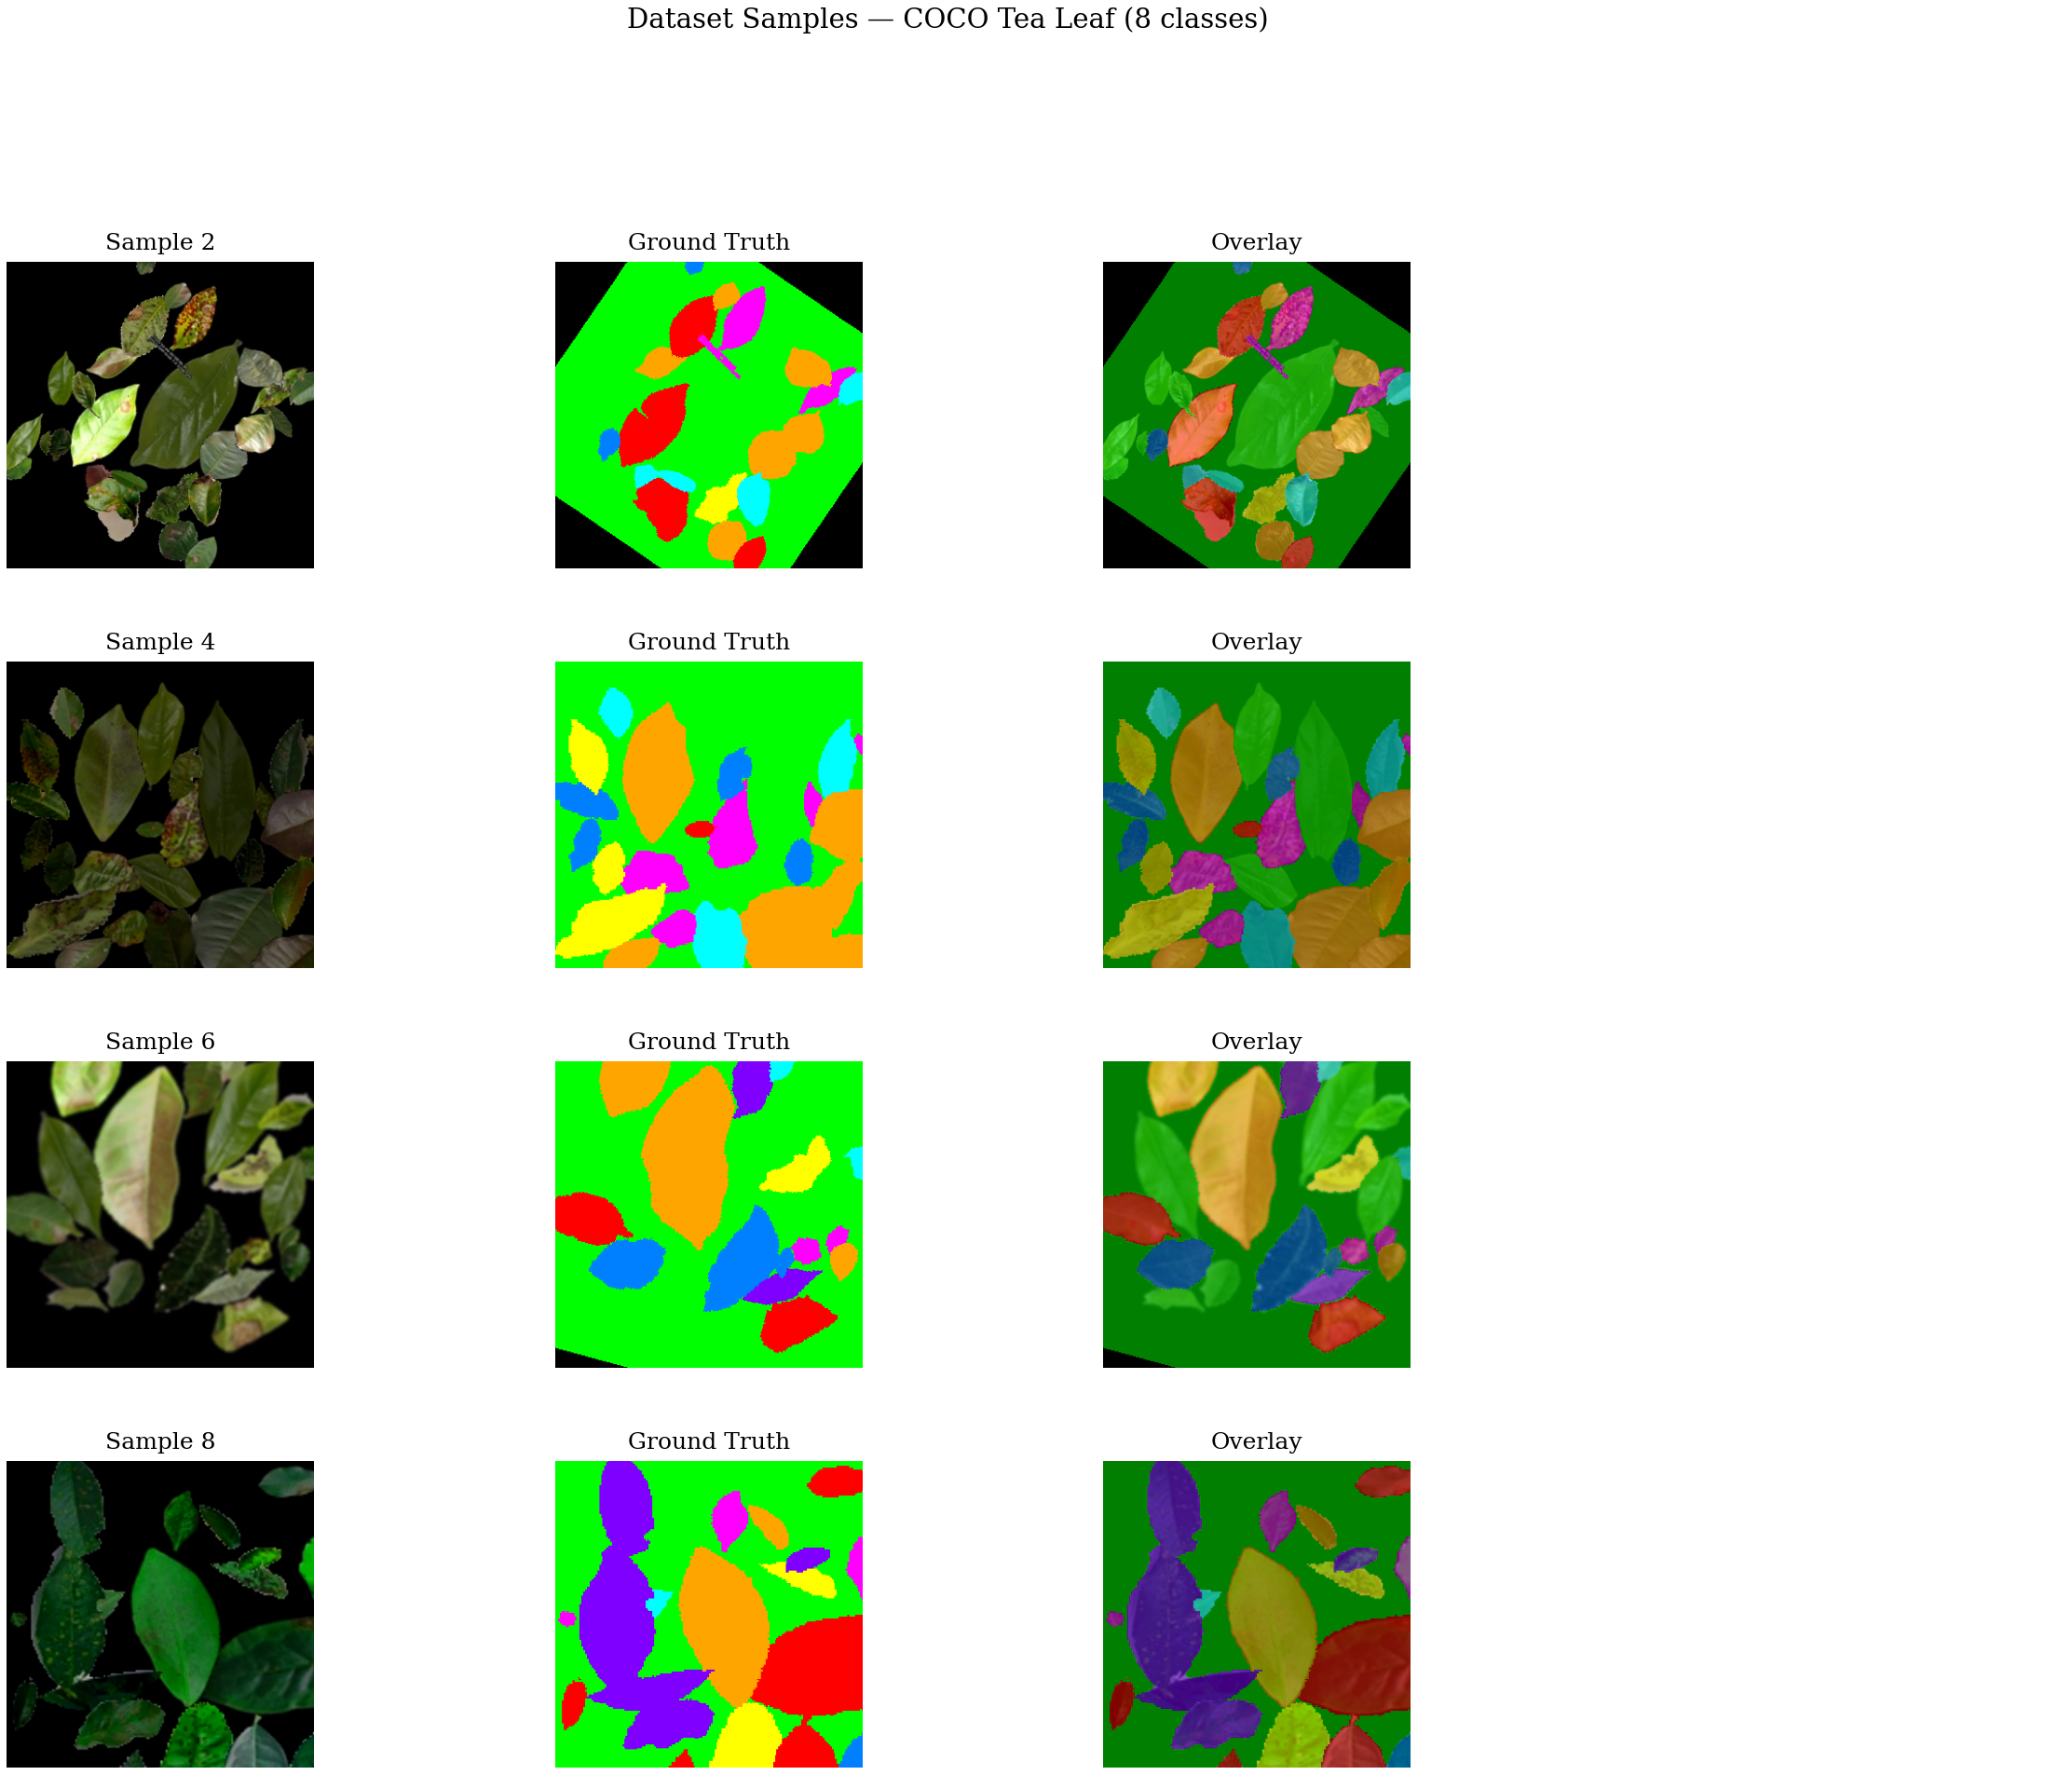

Validation samples:


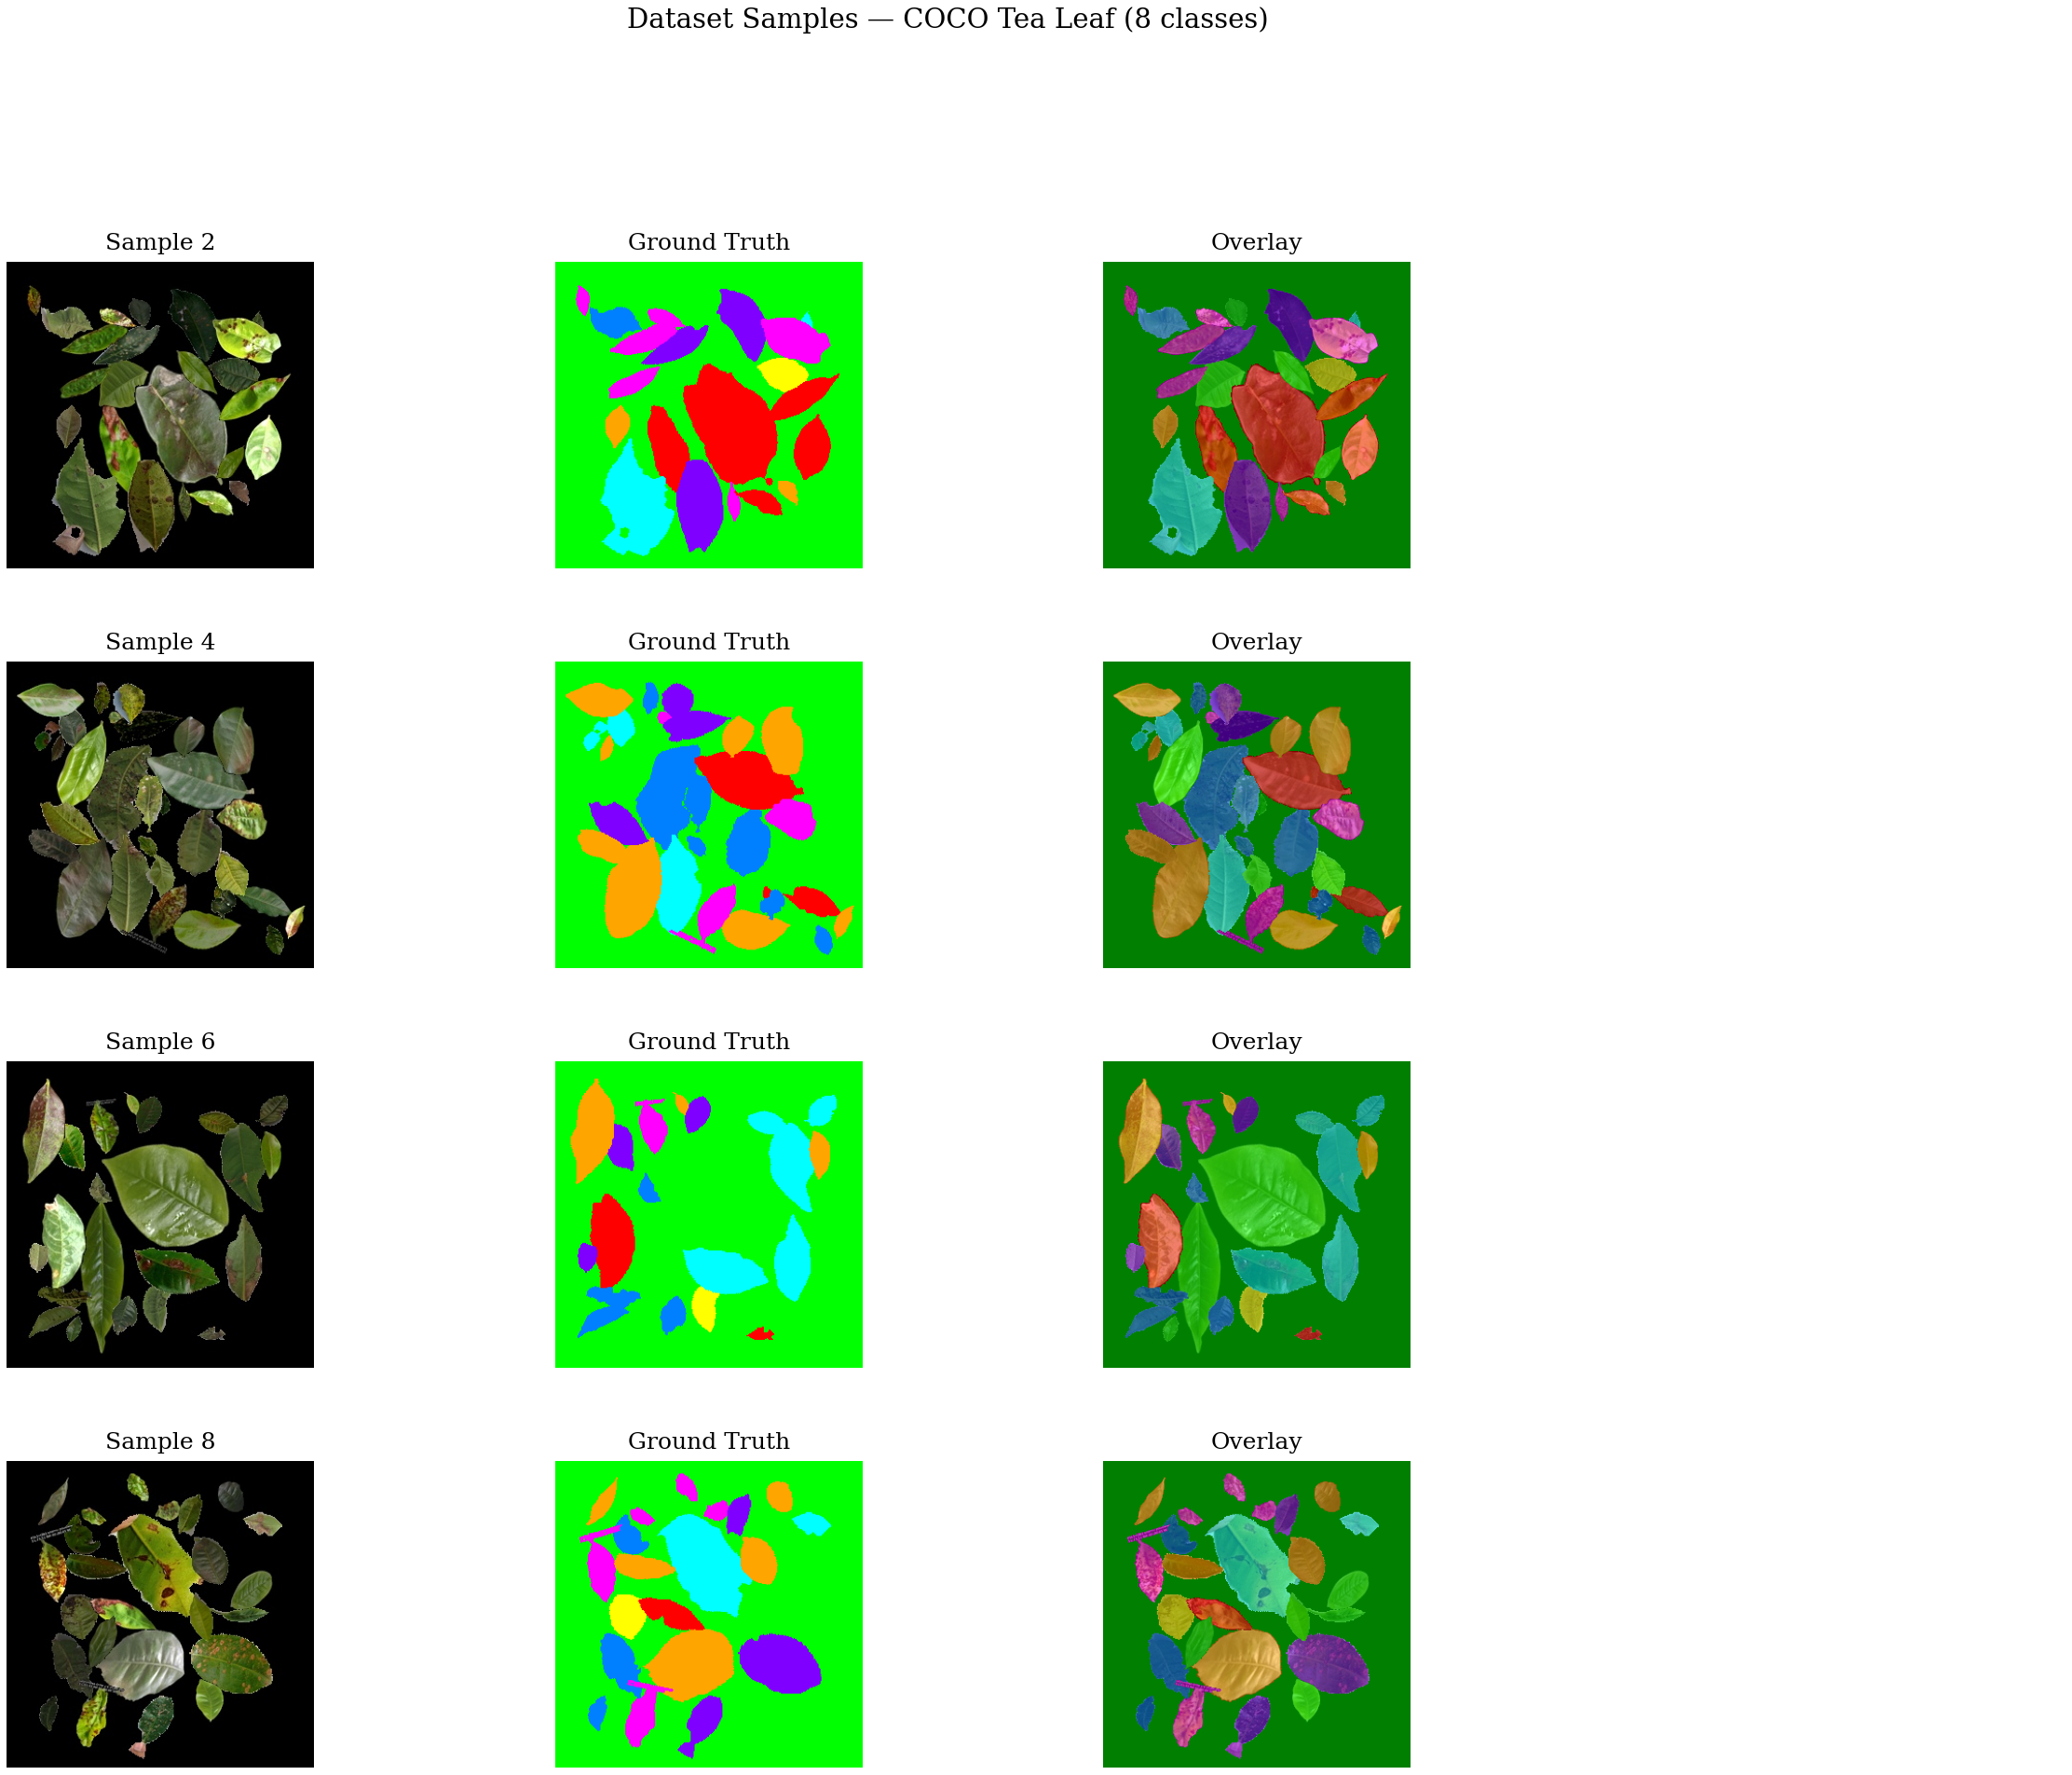

In [5]:
# --- Section 5: Data Visualisation ----------------------------------------------

def visualise_data_samples(labeled_loader, val_loader, info):
    os.makedirs('paper_figures', exist_ok=True)
    print('Labeled training samples (10% of full dataset):')
    show_dataset_samples(
        labeled_loader, info, num_samples=8,
        save_path='paper_figures/01_semitrain_base_train_samples.pdf',
    )
    print('Validation samples:')
    show_dataset_samples(
        val_loader, info, num_samples=8,
        save_path='paper_figures/01_semitrain_base_val_samples.pdf',
    )

visualise_data_samples(labeled_loader, val_loader, info)


In [6]:
# --- Section 6: Mean Teacher Training Setup -------------------------------------

def configure_mean_teacher(model, device, info, config, labeled_loader):
    import os
    save_dir = f"./checkpoints/{config['dataset']}/semitrain_{config['variant']}"
    os.makedirs(save_dir, exist_ok=True)

    # Class weights from labeled data only
    class_weights = None
    pos_weight = None
    if config['use_class_weights'] and info.type == 'multi-class':
        print("\nComputing class weights from labeled training data ...")
        class_weights = compute_class_weights(
            labeled_loader, info.num_classes,
            ignore_index=info.ignore_index, device=device,
        )
    elif info.type == 'binary':
        pos_weight = compute_pos_weight(labeled_loader, device=device)

    # Mean Teacher configuration
    training_cfg = MeanTeacherConfig(
        lr=config['lr'],
        weight_decay=config['weight_decay'],
        warmup_epochs=config['warmup_epochs'],
        scheduler_type=config['scheduler'],
        poly_power=config.get('poly_power', 0.9),
        label_smoothing=config.get('label_smoothing', 0.0),
        use_checkpointing=True,
        nan_recovery=True,
        # Mean Teacher specific
        consistency_weight=config['consistency_weight'],
        teacher_ema_decay=config['teacher_ema_decay'],
        labeled_ratio=config['labeled_ratio'],
        consistency_rampup=config['consistency_rampup'],
    )

    trainer = MeanTeacherTrainer(
        student_model=model,
        device=device,
        dataset_info=info,
        save_dir=save_dir,
        config=training_cfg,
        class_weights=class_weights,
        pos_weight=pos_weight,
    )

    metric = "Dice" if info.type == "binary" else "mIoU"
    print("\nMean Teacher Training Configuration:")
    print(f'  Student optim:  AdamW (lr={config["lr"]}, wd={config["weight_decay"]})')
    print(f'  Scheduler:      {config["scheduler"].upper()} + Warmup ({config["warmup_epochs"]} ep)')
    print(f'  Teacher:        EMA decay={config["teacher_ema_decay"]}')
    print("  Sup loss:       CE + Dice (50/50)")
    print("  Cons loss:      MSE(student_softmax, teacher_softmax)")
    print(f'  Cons weight:    {config["consistency_weight"]} (rampup over {config["consistency_rampup"]} epochs)')
    print(f'  Labeled ratio:  {config["labeled_ratio"]:.0%}')
    print("  Validation:     Teacher model")
    print(f"  Metric:         {metric}")
    print(f"  Checkpoint:     {save_dir}")
    return trainer

trainer = configure_mean_teacher(model, device, info, CFG, labeled_loader)



Computing class weights from labeled training data ...
[Class Weights] Scanning training set for class frequencies ...


  Class  0: 31.15%  weight=0.3100
  Class  1: 13.09%  weight=0.7378
  Class  2: 14.61%  weight=0.6608
  Class  3: 10.10%  weight=0.9556
  Class  4: 10.05%  weight=0.9605
  Class  5:  5.03%  weight=1.9210
  Class  6:  8.98%  weight=1.0753
  Class  7:  7.00%  weight=1.3793
[Checkpointing] enabled on 11 layers

Mean Teacher Training Configuration:
  Student optim:  AdamW (lr=0.01, wd=0.001)
  Scheduler:      POLY + Warmup (5 ep)
  Teacher:        EMA decay=0.999
  Sup loss:       CE + Dice (50/50)
  Cons loss:      MSE(student_softmax, teacher_softmax)
  Cons weight:    10.0 (rampup over 50 epochs)
  Labeled ratio:  10%
  Validation:     Teacher model
  Metric:         mIoU
  Checkpoint:     ./checkpoints/coco_leaf/semitrain_base


In [7]:
# --- Section 7: Mean Teacher Training -------------------------------------------

def run_training(trainer, labeled_loader, unl_s_loader, unl_t_loader, val_loader, config):
    import time
    t_start = time.time()

    history = trainer.train(
        labeled_loader=labeled_loader,
        unlabeled_student_loader=unl_s_loader,
        unlabeled_teacher_loader=unl_t_loader,
        val_loader=val_loader,
        epochs=config['epochs'],
        patience=config['patience'],
        min_epochs=config['min_epochs'],
        save_prefix='best',
    )

    elapsed = time.time() - t_start
    hours, rem = divmod(elapsed, 3600)
    minutes, seconds = divmod(rem, 60)
    print(f"\nTotal training time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")
    return history

history = run_training(trainer, labeled_loader, unl_s_loader, unl_t_loader, val_loader, CFG)


/home/sanng/miniconda3/envs/vision_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(



  Mean Teacher Semi-Supervised Training
  Labeled:           803 samples (10.0%)
  Unlabeled:         7235 samples (90.0%)
  Consistency weight:10.0
  Consistency rampup:50 epochs
  Teacher EMA decay: 0.999



Epoch 1/100 [MTrain]:   0%|          | 0/452 [00:00<?, ?batch/s]/home/sanng/miniconda3/envs/vision_env/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


Epoch 001 | LR: 0.004000 [PolyLR] | Time: 175s | Train: loss=1.3510 sup=1.3490 cons=0.0301 (×0.01) | Val: loss=1.4276 ce=1.9930 dice=0.8621 mIoU=0.1370
  Best model (mIoU=0.1370)



Epoch 002 | LR: 0.006000 [PolyLR] | Time: 178s | Train: loss=1.2442 sup=1.2414 cons=0.0338 (×0.01) | Val: loss=1.3337 ce=1.8455 dice=0.8219 mIoU=0.1887
  Best model (mIoU=0.1887)



Epoch 003 | LR: 0.008000 [PolyLR] | Time: 177s | Train: loss=1.1813 sup=1.1773 cons=0.0409 (×0.01) | Val: loss=1.2298 ce=1.6910 dice=0.7686 mIoU=0.2649
  Best model (mIoU=0.2649)



KeyboardInterrupt: 

In [ ]:
# --- Section 8: Training Curves --------------------------------------------------

def plot_results(history, info, config, trainer):
    metric_name = "Dice" if info.type == "binary" else "mIoU"
    best_epoch = trainer.best_epoch
    best_metric = max(history['val_metric'])
    best_loss = min(history['val_loss'])

    print(f"\nBest validation {metric_name}: {best_metric:.4f} (epoch {best_epoch})")
    print(f"Best validation loss:       {best_loss:.4f}")

    # Print supervised + consistency losses if available
    if 'train_sup_loss' in history and 'train_cons_loss' in history:
        min_sup = min(history['train_sup_loss'])
        min_cons = min(history['train_cons_loss'])
        print(f"Best supervised loss:      {min_sup:.4f}")
        print(f"Best consistency loss:     {min_cons:.4f}")

    os.makedirs('paper_figures', exist_ok=True)
    plot_training_curves(
        history, metric_name=metric_name,
        save_path=f"paper_figures/01_semitrain_base_training_curves_{config['dataset']}.pdf",
    )

    # Extra plot: supervised vs consistency loss breakdown
    if 'train_sup_loss' in history and 'train_cons_loss' in history:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        # Supervised loss
        ax = axes[0]
        ax.plot(history['train_sup_loss'], label='Train Supervised', linewidth=1.5)
        ax.plot(history['val_loss'], label='Val Loss', linewidth=1.5)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Supervised Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        # Consistency loss
        ax = axes[1]
        ax.plot(history['train_cons_loss'], label='Train Consistency',
                color='orange', linewidth=1.5)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.set_title('Consistency Loss (MSE)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        save_path = f"paper_figures/01_semitrain_base_loss_breakdown_{config['dataset']}.pdf"
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved loss breakdown to {save_path}")

plot_results(history, info, CFG, trainer)


In [ ]:
# --- Section 9: Predictions (Teacher Model) -------------------------------------

def show_val_predictions(model, val_loader, device, info, trainer):
    import os
    best_path = os.path.join(trainer.save_dir, 'best_model.pth')
    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device, weights_only=True)
        # Use teacher weights for predictions (teacher = EMA of student)
        if 'teacher_state_dict' in ckpt:
            model.load_state_dict(ckpt['teacher_state_dict'])
            print(f"\nLoaded best TEACHER checkpoint from epoch {ckpt['epoch']}")
        else:
            model.load_state_dict(ckpt['model_state_dict'])
            print(f"\nLoaded best STUDENT checkpoint from epoch {ckpt['epoch']}")
    else:
        # Fallback: use current teacher model
        model.load_state_dict(trainer.teacher.state_dict())
        print("\nNo best checkpoint found; using current teacher weights.")

    model.to(device)
    os.makedirs('paper_figures', exist_ok=True)
    show_predictions(
        model, val_loader, device, info, num_samples=8,
        save_path='paper_figures/01_semitrain_base_predictions.pdf',
    )

show_val_predictions(model, val_loader, device, info, trainer)


In [ ]:
# --- Section 10: Comprehensive Analysis -----------------------------------------

def run_full_analysis(model, val_loader, device, info):
    import numpy as np
    from tqdm import tqdm

    model.eval()
    num_classes = info.num_classes
    ignore_index = info.ignore_index
    class_names = info.class_names

    intersection = torch.zeros(num_classes, device=device)
    union = torch.zeros(num_classes, device=device)
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    all_targets = []

    for images, masks in tqdm(val_loader, desc='[Analysis]', unit='batch', leave=False):
        images_gpu = images.to(device)
        with torch.no_grad():
            outputs = model(images_gpu)  # FP32, no autocast
        preds = outputs.argmax(dim=1).cpu()
        preds_dev = preds.to(device)
        masks_dev = masks.to(device)
        valid = (masks_dev != ignore_index)

        for c in range(num_classes):
            t_c = (masks_dev == c)
            p_c = (preds_dev == c) & valid
            intersection[c] += (p_c & t_c).float().sum()
            union[c] += (p_c | t_c).float().sum()

        valid_flat = (masks_dev != ignore_index)
        for c in range(num_classes):
            t_c = (masks_dev == c) & valid_flat
            if t_c.sum() == 0:
                continue
            pred_flat = preds_dev[valid_flat]
            confusion[c] += torch.bincount(
                pred_flat[t_c[valid_flat]], minlength=num_classes,
            ).cpu()

        all_targets.append(masks)

    # Per-class IoU
    per_class_iou = []
    for c in range(num_classes):
        iou_c = (intersection[c].item() + 1e-6) / (union[c].item() + 1e-6)
        per_class_iou.append(min(iou_c, 1.0))
    mean_iou = np.mean(per_class_iou)

    print(f"\nMean IoU: {mean_iou:.4f}")
    header = f'\n{"Class":<30s} {"IoU":>8s}  {"Status":>8s}'
    print(header)
    print("-" * 52)
    for c in range(num_classes):
        status = "GOOD" if per_class_iou[c] >= 0.7 else ("OK" if per_class_iou[c] >= 0.5 else "LOW")
        print(f"  {class_names[c]:<28s} {per_class_iou[c]:>6.4f}  {status:>8s}")

    # Confusion matrix normalised
    cm_np = confusion.numpy()
    cm_norm = cm_np.astype(np.float64)
    for c in range(num_classes):
        row_sum = cm_norm[c].sum()
        if row_sum > 0:
            cm_norm[c] /= row_sum

    # Pixel distribution
    all_targets = torch.cat(all_targets).numpy()
    total_pixels = (all_targets != ignore_index).sum()
    print("\nPixel distribution:")
    for c in range(num_classes):
        cnt = (all_targets == c).sum()
        print(f"  {class_names[c]:<28s} {cnt:>10,}  ({cnt/total_pixels*100:>5.1f}%)")

    os.makedirs('paper_figures', exist_ok=True)

    plot_per_class_iou(
        class_names, per_class_iou,
        save_path='paper_figures/01_semitrain_base_per_class_iou.pdf',
    )
    plot_confusion_matrix(
        cm_np, cm_norm, class_names,
        save_path='paper_figures/01_semitrain_base_confusion_matrix.pdf',
    )

    return {'per_class_iou': per_class_iou, 'mean_iou': mean_iou,
            'confusion': cm_np, 'confusion_norm': cm_norm}

analysis = run_full_analysis(model, val_loader, device, info)


In [ ]:
# --- Section 11: Summary ---------------------------------------------------------

def print_summary(config, n_params, info, history, analysis, trainer):
    metric_name = "Dice" if info.type == "binary" else "mIoU"
    best_epoch = trainer.best_epoch
    best_metric = max(history['val_metric'])
    best_loss = min(history['val_loss'])

    print("=" * 72)
    print("  EXPERIMENT SUMMARY | U-MobileViT-NET BASE -- Mean Teacher")
    print("=" * 72)
    print("  Method:            Mean Teacher (Semi-Supervised)")
    print(f"  Dataset:           {info.name}")
    print(f'  Model variant:     {config["variant"].upper()}')
    print(f"  Parameters:        {n_params:,} ({n_params/1e6:.2f} M)")
    print(f'  Input resolution:  {config["image_size"]}')
    print(f"  Classes:           {info.num_classes} ({info.type})")
    print(f'  Labeled samples:   {int(info.train_size * config["labeled_ratio"]):,}')
    print(f'  Unlabeled samples: {int(info.train_size * (1 - config["labeled_ratio"])):,}')
    print(f"  Validation samples:{info.val_size:,}")
    print(f'  Labeled ratio:     {config["labeled_ratio"]:.0%}')
    print(f'  Consistency weight:{config["consistency_weight"]}')
    print(f'  Teacher EMA decay: {config["teacher_ema_decay"]}')
    print(f'  Augmentation:      {config["aug_intensity"]}')
    print(f'  Optimiser:         AdamW (lr={config["lr"]}, wd={config["weight_decay"]})')
    print(f'  Scheduler:         {config["scheduler"].upper()} + Warmup ({config["warmup_epochs"]} ep)')
    print(f'  Label smoothing:   {config.get("label_smoothing", 0.0)}')
    print(f'  Class weights:     {config.get("use_class_weights", False)}')
    print(f"  Best epoch:        {best_epoch}")
    print(f"  Best {metric_name}:          {best_metric:.4f}")
    print(f'  Mean per-class IoU:{analysis["mean_iou"]:.4f}')
    print(f"  Best val loss:     {best_loss:.4f}")
    print(f"  Checkpoint:        {trainer.save_dir}")
    print("=" * 72)

print_summary(CFG, n_params, info, history, analysis, trainer)
